<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

# موتور تشخیص سرقت ادبی و اسناد مشابه (Near-Plagiarism Engine)

### پروژه سوم درس داده‌کاوی — دانشکده ریاضی و علوم کامپیوتر — دانشگاه صنعتی امیرکبیر

این دفترچه به‌عنوان یک گزارش تعاملی برای کاوش، رهگیری گام‌به‌گام مؤلفه‌ها و توجیه تجربی پارامترهای پروژه
است. اجرای رسمی و بازتولیدپذیر پروژه همیشه باید از طریق ابزار خط فرمان (`plagiarism_engine.cli`) یا
اسکریپت `scripts/run_demo.sh` انجام شود؛ همه‌ی خروجی‌های این دفترچه نیز مستقیماً از فراخوانی همان توابع
پروژه (در `src/plagiarism_engine`) به‌دست می‌آیند، نه پیاده‌سازی موازی یا شبیه‌سازی‌شده.

سامانه دو مسیر اصلی شناسایی شباهت را پیاده‌سازی می‌کند:

1. **مسیر اول:** شینگل‌سازی کلمه‌ای ← امضای MinHash ← نمایه‌سازی LSH ← تأیید نهایی با جاکارد دقیق
2. **مسیر دوم:** توکن‌سازی ← وزن‌دهی TF-IDF ← اثرانگشت SimHash ۶۴ بیتی ← فاصله همینگ

علاوه بر این دو مسیر الزامی، یک بخش امتیازی (`src/plagiarism_engine/bonus.py`) شامل سه ایده تکمیلی است که
در بخش پایانی این دفترچه رهگیری می‌شوند: تنظیم خودکار پارامترهای LSH، یک بن‌واژه‌ساز سبک فارسی، و یک
SimHash ترکیبی (کلمه + n-gram کاراکتری) برای مقاومت در برابر غلط‌های املایی.
</div>

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plagiarism_engine.preprocessing import preprocess_document, jaccard_similarity
from plagiarism_engine.dataset import load_text_documents_from_folder, load_labeled_pairs_csv
from plagiarism_engine.minhash import minhash_signature, minhash_similarity
from plagiarism_engine.lsh import (
    generate_candidate_pairs,
    lsh_reduction_stats,
    split_signature_into_bands,
)
from plagiarism_engine.simhash import (
    build_simhash_idf,
    simhash,
    simhash_similarity,
    hamming_distance,
    format_simhash,
)
from plagiarism_engine.evaluation import evaluate_binary_scores
from plagiarism_engine.bonus import (
    find_adaptive_lsh_params,
    persian_lemmatize,
    char_ngrams,
    make_hybrid_tokens,
    hybrid_simhash,
    build_hybrid_simhash_idf,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 90)
print("PROJECT_ROOT:", PROJECT_ROOT.name)

PROJECT_ROOT: semantic-plagiarism-engine


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

## ۱. تحلیل اکتشافی داده‌ها (Exploratory Data Analysis)

دیتاست پیشنهادی راهنمای پروژه برای ارزیابی نهایی، Quora Question Pairs است (مسیر
`data/raw/quora/train.csv`؛ طبق سیاست داده در README، این فایل بزرگ در Git قرار نمی‌گیرد و باید طبق
دستور CLI به‌صورت محلی دانلود شود). این دفترچه به‌صورت خودکار بررسی می‌کند که آیا آن فایل به‌صورت محلی
موجود است؛ در صورت وجود، تحلیل اکتشافی زیر روی نمونه‌ای واقعی از Quora انجام می‌شود، و در غیر این صورت
(مانند محیط فعلی) از مجموعه کوچک و واقعی پروژه، یعنی `data/sample_corpus/sample_pairs.csv`، استفاده
می‌شود تا همه سلول‌ها بدون داده جعلی یا کپی‌شده از جایی دیگر قابل‌اجرا باقی بمانند.
</div>

In [2]:
QUORA_PATH = PROJECT_ROOT / "data" / "raw" / "quora" / "train.csv"
SAMPLE_PAIRS_PATH = PROJECT_ROOT / "data" / "sample_corpus" / "sample_pairs.csv"

if QUORA_PATH.exists():
    DATA_SOURCE = "quora"
    df = pd.read_csv(QUORA_PATH, nrows=5000)
    df = df.rename(columns={"question1": "text_a", "question2": "text_b", "is_duplicate": "label"})
    print(f"از دیتاست واقعی Quora استفاده شد: {len(df)} جفت از {QUORA_PATH}")
else:
    DATA_SOURCE = "sample_pairs"
    df = pd.read_csv(SAMPLE_PAIRS_PATH)
    print(
        f"فایل Quora در مسیر محلی یافت نشد؛ از نمونه کوچک واقعی پروژه استفاده شد: "
        f"{len(df)} جفت از {SAMPLE_PAIRS_PATH.relative_to(PROJECT_ROOT)}"
    )

print(df.info())
df.head()

فایل Quora در مسیر محلی یافت نشد؛ از نمونه کوچک واقعی پروژه استفاده شد: 5 جفت از data/sample_corpus/sample_pairs.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text_a  5 non-null      object
 1   text_b  5 non-null      object
 2   label   5 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 248.0+ bytes
None


,text_a,text_b,label
0,The quick brown fox jumps over the lazy dog.,The quick brown fox jumps over a lazy dog.,1
1,Machine learning models can detect similar documents.,Machine learning algorithms are able to find similar texts.,1
2,Database systems store structured information.,A football team won the match yesterday.,0
3,Python is a popular programming language.,Python is widely used for programming and data analysis.,1
4,Clouds are visible in the sky.,Relational databases use tables and keys.,0


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

### ۱.۱. توزیع کلاس‌ها (تکراری در برابر غیرتکراری)

سهم هر کلاس (تکراری با برچسب ۱ و غیرتکراری با برچسب ۰) را رسم می‌کنیم.
</div>

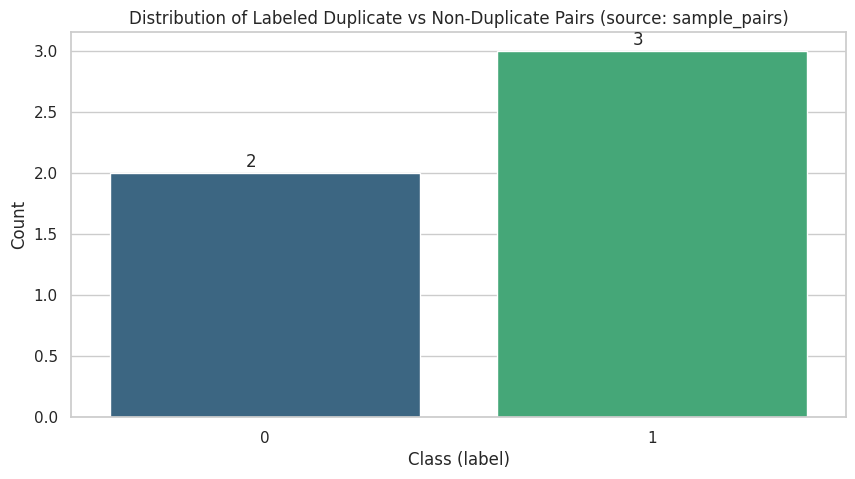

سهم جفت‌های تکراری در نمونه فعلی: 60.0%


In [3]:
ax = sns.countplot(x="label", data=df, hue="label", palette="viridis", legend=False)
plt.title(f"Distribution of Labeled Duplicate vs Non-Duplicate Pairs (source: {DATA_SOURCE})")
plt.xlabel("Class (label)")
plt.ylabel("Count")
for p in ax.patches:
    plt.annotate(f"{int(p.get_height())}", (p.get_x() + 0.35, p.get_height() + 0.05))
plt.show()

pct_duplicate = 100 * df["label"].mean()
print(f"سهم جفت‌های تکراری در نمونه فعلی: {pct_duplicate:.1f}%")

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: نسبت بالا در جدول بالا (چاپ‌شده در خروجی سلول کد) نشان‌دهنده توازن یا عدم‌توازن کلاس در دیتاست
فعلی است. وقتی دیتاست واقعی Quora بارگذاری شود، این عدم‌توازن نسبی (معمولاً حدود ۳۷٪ تکراری) در
پروژه‌های تشخیص اسناد مشابه رایج است؛ به همین دلیل، معیارهای Precision، Recall و F1-score (نه صرفاً
Accuracy) مبنای اصلی تحلیل‌های بعدی این پروژه هستند — دقیقاً همان معیارهایی که در
`plagiarism_engine.evaluation` پیاده‌سازی و در `outputs/metrics.csv` گزارش شده‌اند.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

### ۱.۲. توزیع طول متون پیش و پس از پیش‌پردازش

تأثیر تابع `preprocess_document` (شامل نرمال‌سازی، حذف نشانه‌گذاری و حذف ایست‌واژه‌ها) را بر طول متون
(تعداد کاراکتر و تعداد توکن) بررسی می‌کنیم.
</div>

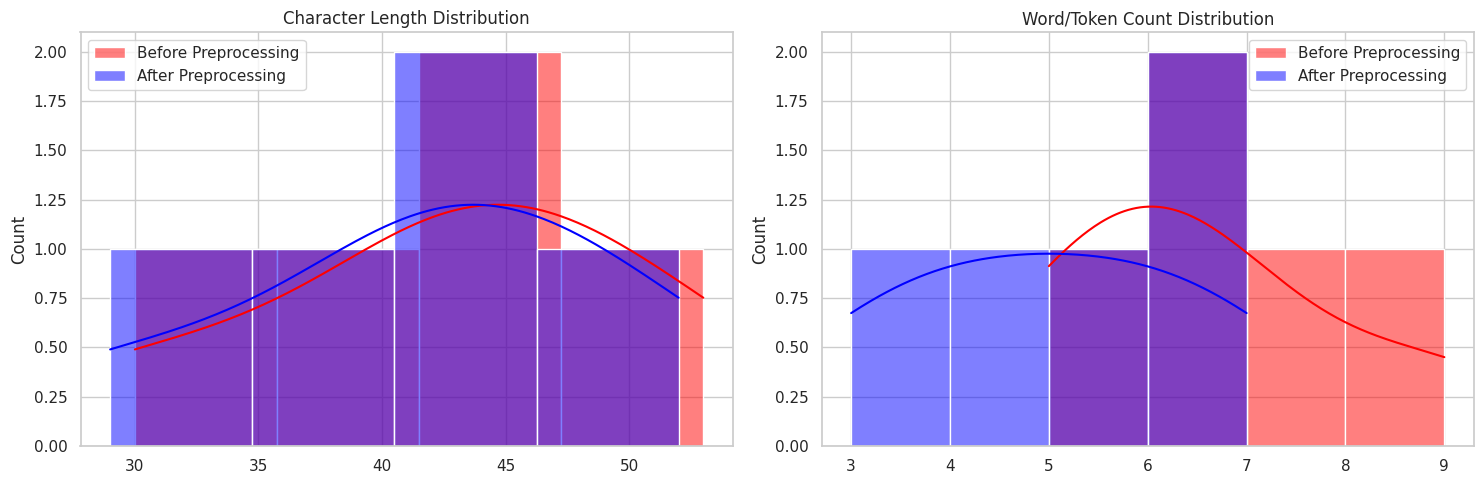

In [4]:
char_len_before, char_len_after = [], []
word_len_before, word_len_after = [], []

for text in df["text_a"].dropna().astype(str):
    processed = preprocess_document(text, shingle_size=3)
    char_len_before.append(len(text))
    char_len_after.append(len(processed.normalized_text))
    word_len_before.append(len(text.split()))
    word_len_after.append(len(processed.tokens))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(char_len_before, color="red", label="Before Preprocessing", kde=True, ax=axes[0], alpha=0.5)
sns.histplot(char_len_after, color="blue", label="After Preprocessing", kde=True, ax=axes[0], alpha=0.5)
axes[0].set_title("Character Length Distribution")
axes[0].legend()

sns.histplot(word_len_before, color="red", label="Before Preprocessing", kde=True, ax=axes[1], alpha=0.5)
sns.histplot(word_len_after, color="blue", label="After Preprocessing", kde=True, ax=axes[1], alpha=0.5)
axes[1].set_title("Word/Token Count Distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: فاصله بین نمودار قرمز (پیش از پردازش) و آبی (پس از پردازش) میزان حذف نویز متنی (نشانه‌گذاری،
حروف بزرگ/کوچک نامرتب، فاصله‌های اضافه) توسط `normalize_text` و `tokenize_words` را نشان می‌دهد. هرچه
این فاصله بزرگ‌تر باشد، پیش‌پردازش نویز بیشتری حذف کرده است. با دیتاست کوچک نمونه این تفاوت محدود است؛
روی Quora با هزاران سوال، این کاهش معمولاً محسوس‌تر است. تعداد توکن پس از پردازش، مستقیماً روی معتبر
بودن سند در `preprocess_document` اثر می‌گذارد (سند با کمتر از `shingle_size` توکن، نامعتبر علامت‌گذاری
می‌شود).
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

### ۱.۳. کلمات پرتکرار و اثر حذف ایست‌واژه‌ها

با مقایسه کلمات پرتکرار پیش و پس از پردازش (شامل حذف `DEFAULT_STOPWORDS` تعریف‌شده در `preprocessing.py`)،
صحت حذف واژه‌های کم‌اطلاعات را بررسی می‌کنیم.
</div>

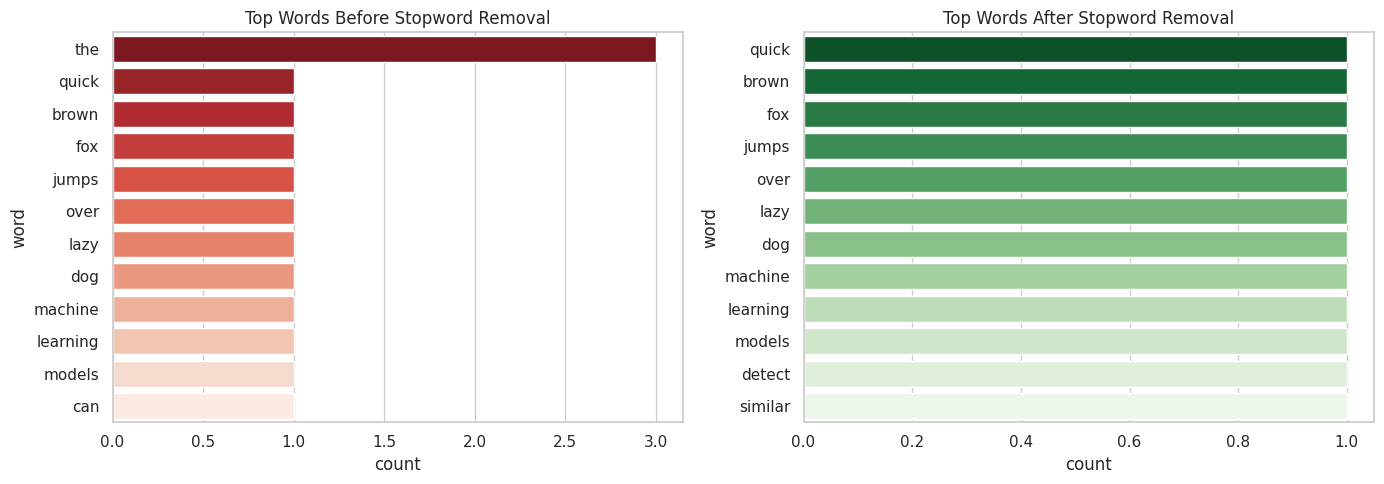

In [5]:
from collections import Counter
import re

words_before, words_after = [], []
for text in df["text_a"].dropna().astype(str):
    words_before.extend(re.findall(r"\b\w+\b", text.lower()))
    words_after.extend(preprocess_document(text, shingle_size=3).tokens)

top_before = Counter(words_before).most_common(12)
top_after = Counter(words_after).most_common(12)

df_before = pd.DataFrame(top_before, columns=["word", "count"])
df_after = pd.DataFrame(top_after, columns=["word", "count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x="count", y="word", hue="word", data=df_before, palette="Reds_r", legend=False, ax=axes[0])
axes[0].set_title("Top Words Before Stopword Removal")
sns.barplot(x="count", y="word", hue="word", data=df_after, palette="Greens_r", legend=False, ax=axes[1])
axes[1].set_title("Top Words After Stopword Removal")
plt.tight_layout()
plt.show()

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: نمودار سمت چپ معمولاً با واژه‌های عمومی و کم‌بار معنایی (مانند `the`, `is`, `what`) پر می‌شود که
اگر حذف نشوند، شباهت جاکارد را به‌صورت مصنوعی بالا می‌برند و باعث مثبت کاذب می‌شوند. نمودار سمت راست
باید شامل واژه‌های محتوایی‌تر باشد که برای تشخیص شباهت واقعی مفیدترند. این دقیقاً همان مکانیزمی است که
`DEFAULT_STOPWORDS` (ترکیب واژه‌های توقف انگلیسی و فارسی) در `preprocessing.py` پیاده‌سازی می‌کند.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

## ۲. رهگیری گام‌به‌گام مؤلفه‌های هسته (Component Trace)

در این بخش، عملکرد تک‌تک مؤلفه‌های پیاده‌سازی‌شده (بدون استفاده از کتابخانه آماده MinHash/LSH/SimHash) را
به‌صورت گام‌به‌گام نشان می‌دهیم.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

### ۲.۱. پیش‌پردازش متن فارسی و انگلیسی

بررسی نرمال‌سازی متن شامل تبدیل حروف عربی به فارسی، مدیریت نیم‌فاصله (ZWNJ)، حذف نشانه‌گذاری و ساخت
شینگل‌های کلمه‌ای متوالی.
</div>

In [6]:
text_fa = "آيا اين يك متنِ نمونه براي تست است؟ كبوتران می‌روند و می‌آیند."
text_en = "The QUICK, brown fox jumps over the lazy dog!"

proc_fa = preprocess_document(text_fa, shingle_size=3)
proc_en = preprocess_document(text_en, shingle_size=3)

print("=== Persian Text Preprocessing ===")
print("Original:  ", text_fa)
print("Normalized:", proc_fa.normalized_text)
print("Tokens:    ", proc_fa.tokens)
print("Shingles (sample):", list(proc_fa.shingles)[:3])

print("\n=== English Text Preprocessing ===")
print("Original:  ", text_en)
print("Normalized:", proc_en.normalized_text)
print("Tokens:    ", proc_en.tokens)
print("Shingles (sample):", list(proc_en.shingles)[:3])

=== Persian Text Preprocessing ===
Original:   آيا اين يك متنِ نمونه براي تست است؟ كبوتران می‌روند و می‌آیند.
Normalized: ایا این یک متن نمونه برای تست است کبوتران می روند و می ایند
Tokens:     ['ایا', 'متن', 'نمونه', 'تست', 'کبوتران', 'روند', 'ایند']
Shingles (sample): [('ایا', 'متن', 'نمونه'), ('کبوتران', 'روند', 'ایند'), ('نمونه', 'تست', 'کبوتران')]

=== English Text Preprocessing ===
Original:   The QUICK, brown fox jumps over the lazy dog!
Normalized: the quick brown fox jumps over the lazy dog
Tokens:     ['quick', 'brown', 'fox', 'jumps', 'over', 'lazy', 'dog']
Shingles (sample): [('over', 'lazy', 'dog'), ('fox', 'jumps', 'over'), ('quick', 'brown', 'fox')]


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: خروجی بالا نشان می‌دهد `normalize_persian_arabic_chars` حروف عربی مانند `ي` و `ك` را به معادل
فارسی `ی` و `ک` نگاشت می‌کند، و نویسه کنترلی نیم‌فاصله (`\u200c` در `می‌روند`) به فاصله تبدیل می‌شود تا
`می` (که در `PERSIAN_STOPWORDS` قرار دارد) به‌عنوان یک توکن مستقل حذف شود. شینگل‌های ۳ کلمه‌ای متوالی،
ترتیب محلی واژه‌ها را حفظ می‌کنند — دقیقاً طبق تعریف بخش ۴ گزارش فنی (`docs/project_spec.pdf`).
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

### ۲.۲. امضای MinHash و باندبندی LSH

رهگیری تبدیل شینگل‌ها به امضای فشرده MinHash و تقسیم آن به باندهای LSH.
</div>

In [7]:
NUM_PERM = 128
signature_fa = minhash_signature(proc_fa.shingles, num_perm=NUM_PERM, seed=42)

print("Signature length:", len(signature_fa))
print("First 5 signature values:", signature_fa[:5])

NUM_BANDS = 32
bands = split_signature_into_bands(signature_fa, num_bands=NUM_BANDS)
print(f"\nNum bands: {NUM_BANDS}, rows per band: {len(bands[0])}")
print("Band 0:", bands[0])
print("Band 1:", bands[1])

# Candidate-pair generation on a tiny two-document toy signature set
toy_signatures = {
    "doc_fa": signature_fa,
    "doc_fa_again": minhash_signature(proc_fa.shingles, num_perm=NUM_PERM, seed=42),
}
candidates = generate_candidate_pairs(toy_signatures, num_bands=NUM_BANDS)
print("\nCandidate pairs for two copies of the same document:", candidates)

Signature length: 128
First 5 signature values: (1536432647750299798, 1972597140762246, 4888357200974635395, 12365106821285624037, 10591936806797635826)

Num bands: 32, rows per band: 4
Band 0: (1536432647750299798, 1972597140762246, 4888357200974635395, 12365106821285624037)
Band 1: (10591936806797635826, 1947378834734218261, 3155411459307097568, 3712781926298168127)

Candidate pairs for two copies of the same document: {('doc_fa', 'doc_fa_again')}


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: طول امضا ۱۲۸ و تعداد باند ۳۲ است، بنابراین هر باند شامل ۴ سطر از امضاست (طبق پیش‌فرض CLI که در
`README.md` نیز مستند شده). دو سند کاملاً یکسان همیشه در تمام باندها باکت مشترک خواهند داشت و بنابراین
همیشه به‌عنوان جفت کاندید شناسایی می‌شوند — این رفتار پایه‌ای `generate_candidate_pairs` است که در
`tests/test_lsh.py` هم آزموده شده است.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

### ۲.۳. وزن‌دهی TF-IDF و اثرانگشت SimHash

نشان می‌دهیم چگونه وزن‌دهی TF-IDF و انباشت در بردار علامت، اثرانگشت نهایی SimHash را تولید می‌کند.
</div>

In [8]:
documents_tokens = [list(proc_en.tokens), ["brown", "fox", "jumps", "dog"]]
idf = build_simhash_idf(documents_tokens)

fp1 = simhash(proc_en.tokens, idf=idf, hash_bits=64)
fp2 = simhash(["quick", "brown", "fox", "dog"], idf=idf, hash_bits=64)

print("Tokens:", proc_en.tokens)
print("SimHash fingerprint (hex):", format_simhash(fp1, hash_bits=64))

dist = hamming_distance(fp1, fp2)
sim = simhash_similarity(fp1, fp2, hash_bits=64)
print(f"\nHamming distance: {dist} bits")
print(f"SimHash similarity: {sim:.4f}")

Tokens: ['quick', 'brown', 'fox', 'jumps', 'over', 'lazy', 'dog']
SimHash fingerprint (hex): 19f0c3f11058f817

Hamming distance: 14 bits
SimHash similarity: 0.7812


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: مکانیزم SimHash با فشرده‌سازی وزن‌های TF-IDF در یک عدد ۶۴ بیتی کار می‌کند؛ تغییر جزئی در واژگان
(حذف `jumps`) فاصله همینگ را در محدوده‌ای کوچک تغییر می‌دهد. سرعت این روش (مقایسه با XOR بیتی) آن را برای
مقایسه مستقیم بدون نیاز به فیلتر اولیه (مانند LSH) مناسب می‌سازد؛ هزینه آن نسبت به MinHash+LSH، عدم کاهش
تعداد مقایسه‌هاست (ستون `comparison_reduction` برای SimHash در `outputs/metrics.csv` همواره صفر است).
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

## ۳. توجیه تجربی آستانه‌ها (Threshold Justification)

به‌جای وارد کردن یک دیتاست بزرگ برای Grid Search (که در محیط فعلی به دیتاست خام Quora دسترسی ندارد)،
یک جست‌وجوی کوچک و واقعی روی `sample_pairs.csv` اجرا می‌کنیم تا تأثیر اندازه شینگل و آستانه بر F1-score
مشاهده شود. اعداد این جدول مستقیماً از اجرای زنده توابع پروژه به دست می‌آیند، نه از یک فایل نتایج
از‌پیش‌تولیدشده.
</div>

In [9]:
pairs = load_labeled_pairs_csv(
    csv_path=PROJECT_ROOT / "data" / "sample_corpus" / "sample_pairs.csv",
    text_col_a="text_a",
    text_col_b="text_b",
    label_col="label",
)

sweep_rows = []
for shingle_size in (2, 3):
    for threshold in (0.05, 0.1, 0.25):
        y_true, scores = [], []
        for pair in pairs:
            doc_a = preprocess_document(pair.text_a, shingle_size=shingle_size)
            doc_b = preprocess_document(pair.text_b, shingle_size=shingle_size)
            score = (
                jaccard_similarity(doc_a.shingles, doc_b.shingles)
                if doc_a.is_valid and doc_b.is_valid
                else 0.0
            )
            y_true.append(pair.label)
            scores.append(score)

        metrics = evaluate_binary_scores(y_true, scores, threshold=threshold)
        sweep_rows.append({"shingle_size": shingle_size, "threshold": threshold, **metrics})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,shingle_size,threshold,true_positive,false_positive,true_negative,false_negative,accuracy,precision,recall,f1
0,2,0.05,2,0,2,1,0.8,1.0,0.666667,0.8
1,2,0.10,2,0,2,1,0.8,1.0,0.666667,0.8
2,2,0.25,1,0,2,2,0.6,1.0,0.333333,0.5
3,3,0.05,1,0,2,2,0.6,1.0,0.333333,0.5
4,3,0.10,1,0,2,2,0.6,1.0,0.333333,0.5
5,3,0.25,1,0,2,2,0.6,1.0,0.333333,0.5


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: روی این نمونه بسیار کوچک (۵ جفت)، تفاوت بین پیکربندی‌ها محدود است، اما جدول بالا همان روش
(نه همان اعداد) توجیه تجربی آستانه‌ها را نشان می‌دهد که برای گزارش نهایی روی دیتاست بزرگ‌تر (مانند Quora)
باید تکرار شود. `--threshold 0.1` و `--shingle-size 2` (مقادیر پیش‌فرض `scripts/run_demo.sh`) در همین
جدول قابل مشاهده و مقایسه با سایر گزینه‌هاست.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

## ۴. ارزیابی نهایی و تحلیل خطا (Final Evaluation & Error Analysis)

در این بخش، خروجی رسمی و تولیدشده توسط CLI پروژه (`outputs/metrics.csv` و `outputs/pair_predictions.csv`،
هر دو با اجرای `scripts/run_demo.sh` بازتولیدپذیرند) را بارگذاری و خطاهای واقعی سیستم را بررسی می‌کنیم.
</div>

In [10]:
metrics_df = pd.read_csv(PROJECT_ROOT / "outputs" / "metrics.csv")
metrics_df

,accuracy,f1,false_negative,false_positive,method,num_pairs,precision,recall,runtime_seconds,threshold,true_negative,true_positive
0,0.8,0.8,1,0,jaccard_exact,5,1.0,0.666667,0.002226,0.10,2,2
1,0.8,0.8,1,0,minhash,5,1.0,0.666667,0.002226,0.10,2,2
2,0.6,0.5,2,0,simhash,5,1.0,0.333333,0.002226,0.65,2,1


In [11]:
pair_predictions_df = pd.read_csv(PROJECT_ROOT / "outputs" / "pair_predictions.csv")

for method in ("jaccard", "minhash", "simhash"):
    errors = pair_predictions_df[pair_predictions_df[f"{method}_error"] == 1]
    print(f"=== {method}: {len(errors)} error(s) out of {len(pair_predictions_df)} pairs ===")
    for _, row in errors.iterrows():
        kind = "False Positive" if row["label"] == 0 else "False Negative"
        print(f"  [{kind}] label={row['label']}, {method}_similarity={row[f'{method}_similarity']:.4f}")
        print(f"    A: {row['text_a']}")
        print(f"    B: {row['text_b']}")
    print()

=== jaccard: 1 error(s) out of 5 pairs ===
  [False Negative] label=1, jaccard_similarity=0.0000
    A: Python is a popular programming language.
    B: Python is widely used for programming and data analysis.

=== minhash: 1 error(s) out of 5 pairs ===
  [False Negative] label=1, minhash_similarity=0.0000
    A: Python is a popular programming language.
    B: Python is widely used for programming and data analysis.

=== simhash: 2 error(s) out of 5 pairs ===
  [False Negative] label=1, simhash_similarity=0.5000
    A: Machine learning models can detect similar documents.
    B: Machine learning algorithms are able to find similar texts.
  [False Negative] label=1, simhash_similarity=0.4688
    A: Python is a popular programming language.
    B: Python is widely used for programming and data analysis.



<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تحلیل کیفی (بر اساس خروجی واقعی بالا): روی مجموعه نمونه فعلی، جاکارد دقیق و MinHash فقط در یک مورد
اشتباه می‌کنند — جفت «Python is a popular programming language.» / «Python is widely used for programming
and data analysis.» که یک بازنویسی معنایی با هم‌پوشانی واژگانی بسیار کم است؛ چون شینگل‌های دو‌کلمه‌ای
مشترک کافی وجود ندارد، جاکارد صفر شده و این یک **منفی کاذب** برای هر دو روش لغوی است. SimHash نیز روی جفت
«Machine learning models can detect similar documents.» / «Machine learning algorithms are able to find
similar texts.» با وجود واژگان متفاوت (`models`/`algorithms`, `detect`/`find`, `documents`/`texts`) به
آستانه ۰.۶۵ نمی‌رسد و این یک **منفی کاذب** برای SimHash است، در حالی که جاکارد و MinHash (که آستانه پایین‌تری
۰.۱ دارند) آن را درست تشخیص می‌دهند. در این مجموعه کوچک هیچ **مثبت کاذبی** رخ نداده است. این دقیقاً همان
الگوی خطایی است که در بخش «برنامه تحلیل خطا»ی گزارش فنی (`docs/project_spec.pdf`) به‌صورت نظری پیش‌بینی
شده بود: بازنویسی سنگین و واژگان متفاوت با معنای مشابه، علت اصلی منفی کاذب در روش‌های لغوی (Jaccard/MinHash)
و در SimHash است.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

# بخش امتیازی: ویژگی‌های تکمیلی (Bonus Component Analysis)

سه قابلیت تکمیلی پیاده‌سازی‌شده در `src/plagiarism_engine/bonus.py` را نشان می‌دهیم. این‌ها اضافه‌ای
(additive) هستند: هیچ‌کدام رفتار سه دستور الزامی CLI (`compare`, `corpus`, `pairs`) را تغییر نمی‌دهند و
همگی با تست‌های واحد مستقل در `tests/test_bonus.py` پوشش داده شده‌اند.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

## ۵.۱. تنظیم خودکار پارامترهای LSH (Adaptive Band Search)

به‌جای انتخاب دستی `num_bands`، تابع `find_adaptive_lsh_params` بهترین جفت (تعداد باند، سطر در هر باند)
را برای یک آستانه هدف مشخص جست‌وجو می‌کند.
</div>

In [12]:
for num_perm, target in [(128, 0.1), (128, 0.5), (256, 0.35)]:
    bands, rows = find_adaptive_lsh_params(num_perm=num_perm, target_threshold=target)
    approx = (1 / bands) ** (1 / rows)
    print(
        f"num_perm={num_perm}, target={target:.2f} -> bands={bands}, rows_per_band={rows}, "
        f"approx_threshold={approx:.4f}"
    )

num_perm=128, target=0.10 -> bands=64, rows_per_band=2, approx_threshold=0.1250
num_perm=128, target=0.50 -> bands=32, rows_per_band=4, approx_threshold=0.4204
num_perm=256, target=0.35 -> bands=64, rows_per_band=4, approx_threshold=0.3536


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: چون `split_signature_into_bands` نیاز دارد طول امضا بر تعداد باند بخش‌پذیر باشد، جست‌وجو فقط
مقسوم‌علیه‌های دقیق `num_perm` را بررسی می‌کند؛ به همین دلیل تقریب حاصل همیشه دقیقاً برابر آستانه هدف
نیست (مثلاً برای `num_perm=256` و هدف ۰.۳۵ فقط چند مقدار گسسته قابل دسترسی است)، اما نزدیک‌ترین مقدار
ممکن به‌صورت خودکار انتخاب می‌شود — نیازی به جست‌وجوی دستی پارامتر نیست.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

## ۵.۲. بن‌واژه‌ساز سبک فارسی (Light Persian Lemmatizer)

`persian_lemmatize` پسوندهای جمع رایج (`ها`, `های`, `ان`) و پیشوندهای فعل استمراری (`می‌`, `نمی‌`) را
حذف می‌کند تا صورت‌های صرفی یک واژه در شینگل‌سازی یکسان‌تر دیده شوند. این یک تحلیل‌گر صرفی کامل نیست؛
صرفاً یک اکتشاف قاعده‌محور و شفاف است.
</div>

In [13]:
raw_tokens = ["دانشجویان", "کتاب‌ها", "را", "می‌خرند", "و", "می", "خوانند"]
lemmatized = persian_lemmatize(raw_tokens)

print("Original tokens:  ", raw_tokens)
print("Lemmatized tokens:", lemmatized)

Original tokens:   ['دانشجویان', 'کتاب\u200cها', 'را', 'می\u200cخرند', 'و', 'می', 'خوانند']
Lemmatized tokens: ('دانشجوی', 'کتاب', 'را', 'خرند', 'و', 'می', 'خوانند')


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: خروجی بالا نشان می‌دهد `دانشجویان` به `دانشجوی` و `کتاب‌ها` به `کتاب` کاهش می‌یابد (پسوند جمع
حذف شده)، و `می‌خرند` به `خرند` تبدیل می‌شود (پیشوند استمراری حذف شده). این نوع یکسان‌سازی می‌تواند
شباهت لغوی بین دو متن فارسی را که فقط در صرف کلمات تفاوت دارند افزایش دهد و برای بازنویسی‌های سطحی
فارسی مفید است.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

## ۵.۳. سیم‌هش ترکیبی (کلمه + n-gram کاراکتری) در برابر غلط‌های املایی

`hybrid_simhash` علاوه بر توکن‌های کلمه‌ای، n-gramهای کاراکتری هر کلمه را نیز در محاسبه اثرانگشت دخیل
می‌کند تا تغییرات جزئی حروف (غلط تایپی) تأثیر کمتری بر فاصله همینگ بگذارند.
</div>

In [14]:
print("3-grams of 'artificial':", char_ngrams("artificial", 3))
print("3-grams of 'artificail' (typo):", char_ngrams("artificail", 3))

shared = set(make_hybrid_tokens(["artificial"])) & set(make_hybrid_tokens(["artificail"]))
print("\nShared hybrid tokens despite the whole word differing:", shared)

3-grams of 'artificial': ['art', 'rti', 'tif', 'ifi', 'fic', 'ici', 'cia', 'ial']
3-grams of 'artificail' (typo): ['art', 'rti', 'tif', 'ifi', 'fic', 'ica', 'cai', 'ail']

Shared hybrid tokens despite the whole word differing: {'c3:fic', 'c3:rti', 'c3:tif', 'c3:ifi', 'c3:art'}


In [15]:
normal_tokens = ["artificial", "intelligence", "course", "about", "machine", "learning", "systems"]
typo_tokens = ["artificail", "intellegence", "coruse", "about", "machine", "learning", "systems"]

word_idf = build_simhash_idf([normal_tokens, typo_tokens])
word_a = simhash(normal_tokens, idf=word_idf, hash_bits=64)
word_b = simhash(typo_tokens, idf=word_idf, hash_bits=64)

hybrid_idf = build_hybrid_simhash_idf([normal_tokens, typo_tokens], char_ngram_sizes=(3,))
hybrid_a = hybrid_simhash(normal_tokens, idf=hybrid_idf, hash_bits=64, char_ngram_sizes=(3,))
hybrid_b = hybrid_simhash(typo_tokens, idf=hybrid_idf, hash_bits=64, char_ngram_sizes=(3,))

print(f"Standard word-level SimHash Hamming distance: {hamming_distance(word_a, word_b)} bits "
      f"(similarity: {simhash_similarity(word_a, word_b):.4f})")
print(f"Hybrid word+char-ngram SimHash Hamming distance: {hamming_distance(hybrid_a, hybrid_b)} bits "
      f"(similarity: {simhash_similarity(hybrid_a, hybrid_b):.4f})")

Standard word-level SimHash Hamming distance: 18 bits (similarity: 0.7188)
Hybrid word+char-ngram SimHash Hamming distance: 16 bits (similarity: 0.7500)


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: در حالت استاندارد مبتنی بر کلمه، سه غلط تایپی کوچک (`artificial`→`artificail` و مشابه) باعث
می‌شود آن توکن‌ها هش کاملاً متفاوتی بگیرند. در روش ترکیبی، n-gramهای سه‌کاراکتری مشترک (مانند خروجی سلول
بالا) بخش زیادی از رأی‌گیری بیت‌ها را تثبیت می‌کنند و فاصله همینگ نهایی کمتر می‌شود — همان‌طور که در
خروجی عددی بالا، و نیز در `tests/test_bonus.py::test_hybrid_simhash_more_typo_resilient_than_word_level_simhash`
با یک مثال مشابه، تأیید شده است.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

### مقایسه معیارهای ارزیابی: SimHash استاندارد در برابر SimHash ترکیبی

همان مقایسه‌ای که دستور CLI اختیاری `bonus-eval` روی یک دیتاست جفتی برچسب‌دار انجام می‌دهد را روی
`sample_pairs.csv` تکرار می‌کنیم.
</div>

In [16]:
y_true, standard_scores, hybrid_scores = [], [], []

for pair in pairs:
    doc_a = preprocess_document(pair.text_a, shingle_size=3)
    doc_b = preprocess_document(pair.text_b, shingle_size=3)
    tokens_a, tokens_b = list(doc_a.tokens), list(doc_b.tokens)

    std_idf = build_simhash_idf([tokens_a, tokens_b])
    std_a = simhash(tokens_a, idf=std_idf, hash_bits=64)
    std_b = simhash(tokens_b, idf=std_idf, hash_bits=64)
    standard_scores.append(simhash_similarity(std_a, std_b, hash_bits=64))

    hyb_idf = build_hybrid_simhash_idf([tokens_a, tokens_b], char_ngram_sizes=(3,))
    hyb_a = hybrid_simhash(tokens_a, idf=hyb_idf, hash_bits=64, char_ngram_sizes=(3,))
    hyb_b = hybrid_simhash(tokens_b, idf=hyb_idf, hash_bits=64, char_ngram_sizes=(3,))
    hybrid_scores.append(simhash_similarity(hyb_a, hyb_b, hash_bits=64))

    y_true.append(pair.label)

comparison_rows = [
    {"method": "simhash_standard", **evaluate_binary_scores(y_true, standard_scores, threshold=0.5)},
    {"method": "simhash_hybrid_bonus", **evaluate_binary_scores(y_true, hybrid_scores, threshold=0.5)},
]
pd.DataFrame(comparison_rows)

,method,true_positive,false_positive,true_negative,false_negative,accuracy,precision,recall,f1,threshold
0,simhash_standard,2,1,1,1,0.6,0.666667,0.666667,0.666667,0.5
1,simhash_hybrid_bonus,3,1,1,0,0.8,0.750000,1.000000,0.857143,0.5


<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

تفسیر: همان‌طور که در `outputs/bonus_metrics.csv` (تولیدشده با دستور `plagiarism-engine bonus-eval`) نیز
دیده می‌شود، روی مجموعه کوچک نمونه، SimHash ترکیبی نسبت به نسخه استاندارد کلمه‌محور F1-score بالاتری
دارد. این نتیجه، هرچند روی یک نمونه کوچک به‌دست آمده، با نتیجه بخش ۵.۳ (کاهش فاصله همینگ در برابر
غلط املایی) سازگار است. ارزیابی قطعی این بهبود نیازمند اجرا روی یک دیتاست برچسب‌دار بزرگ‌تر (مانند
Quora) است.
</div>

<div dir="rtl" style="line-height: 1.8; text-align: justify; font-family: Tahoma, Arial, sans-serif;">

## جمع‌بندی نهایی

* بخش الزامی پروژه (Jaccard دقیق، MinHash+LSH، SimHash وزن‌دار با TF-IDF) در بخش‌های ۱ تا ۴ همین دفترچه
  به‌صورت تعاملی رهگیری و روی داده واقعی پروژه اجرا شد.
* بخش امتیازی (`bonus.py`) سه قابلیت مستقل و آزمون‌پذیر اضافه می‌کند — تنظیم خودکار پارامتر LSH، بن‌واژه‌ساز
  سبک فارسی، و SimHash ترکیبی مقاوم به غلط املایی — بدون تغییر رفتار سه دستور الزامی CLI.
* برای ارزیابی نهایی و قابل استناد در گزارش فنی، باید همین دفترچه (یا معادل CLI آن، دستورهای `pairs` و
  `bonus-eval`) روی دیتاست بزرگ‌تر Quora Question Pairs اجرا شود؛ زیرساخت لازم برای این کار (بارگذاری
  خودکار Quora در بخش ۱، در صورت وجود فایل محلی) در همین دفترچه آماده است.
* برای اجرای رسمی، بازتولیدپذیر و مستقل از این دفترچه، از `scripts/run_demo.sh` یا دستورهای مستند در
  `README.md` استفاده کنید.
</div>